# Parte II -- Analisis de grafos: ranking y comunidades

Corre en la **misma carpeta del Workspace** que la Parte I: reutiliza sus modulos (`config.py`, `preprocessing.py`, `cleaning.py`, `graphs.py`) y los parquet de `artifacts/`.

In [0]:
# Setup: modulos y artifacts de la Parte I (misma carpeta del Workspace).
# load_mod lee los .py directo desde disco (evita el cache de imports del Workspace)
import sys, os, importlib.util

src = os.getcwd()
sys.path.insert(0, src)

def load_mod(name):
    path = os.path.join(src, name + '.py')
    assert os.path.exists(path), f'No existe {path}: corre primero la Parte I en esta carpeta'
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    sys.modules[name] = mod
    spec.loader.exec_module(mod)
    return mod

config = load_mod('config')
preprocessing = load_mod('preprocessing')
cleaning = load_mod('cleaning')
graphs = load_mod('graphs')
print('Artefactos en:', config.ARTIFACTS)

# build_subset() es idempotente: usa el cache parquet si existe,
# y si no (p.ej. cluster nuevo) re-streamea los JSON (~3 min)
clean = cleaning.clean_subset(preprocessing.build_subset())
G = graphs.build_graphs(clean)

In [0]:
%%writefile ranking.py
import math
from collections import defaultdict
import pandas as pd


# ===================== PageRank (grafo de amistad) =====================
def pagerank(adj, nodes=None, d=0.85, max_iter=100, tol=1e-6):
    if nodes is None:
        nodes = list(adj)
    nodeset = set(nodes)
    N = len(nodes)
    nbrs = {u: [v for v in adj[u] if v in nodeset] for u in nodes}
    deg = {u: len(nbrs[u]) for u in nodes}
    pr = {u: 1.0 / N for u in nodes}
    base = (1 - d) / N
    for it in range(1, max_iter + 1):
        new = {u: base for u in nodes}
        dangling = 0.0
        for u in nodes:
            if deg[u] == 0:
                dangling += pr[u]
            else:
                share = d * pr[u] / deg[u]
                for v in nbrs[u]:
                    new[v] += share
        if dangling:
            add = d * dangling / N
            for u in new:
                new[u] += add
        diff = sum(abs(new[u] - pr[u]) for u in nodes)
        pr = new
        if diff < tol:
            break
    return pr, it


def top_pagerank(pr, users, k=15):
    s = pd.Series(pr, name='pagerank').sort_values(ascending=False).head(k)
    out = s.rename_axis('user_id').reset_index()
    cols = ['user_id', 'name', 'review_count', 'fans', 'n_friends_subset']
    info = users[[c for c in cols if c in users.columns]]
    return out.merge(info, on='user_id', how='left')


# ===================== HITS (bipartito usuario-negocio) =====================
def build_review_graph(reviews):
    user_to_biz = defaultdict(list)
    biz_to_users = defaultdict(list)
    for u, b in zip(reviews['user_id'], reviews['business_id']):
        user_to_biz[u].append(b)
        biz_to_users[b].append(u)
    return dict(user_to_biz), dict(biz_to_users)


def hits(user_to_biz, biz_to_users, max_iter=100, tol=1e-8):
    hub = {u: 1.0 for u in user_to_biz}
    auth = {b: 1.0 for b in biz_to_users}
    for it in range(1, max_iter + 1):
        new_auth = {b: sum(hub[u] for u in us) for b, us in biz_to_users.items()}
        na = math.sqrt(sum(v * v for v in new_auth.values())) or 1.0
        new_auth = {b: v / na for b, v in new_auth.items()}
        new_hub = {u: sum(new_auth[b] for b in bs) for u, bs in user_to_biz.items()}
        nh = math.sqrt(sum(v * v for v in new_hub.values())) or 1.0
        new_hub = {u: v / nh for u, v in new_hub.items()}
        diff = (sum(abs(new_auth[b] - auth[b]) for b in auth)
                + sum(abs(new_hub[u] - hub[u]) for u in hub))
        auth, hub = new_auth, new_hub
        if diff < tol:
            break
    return hub, auth, it


def top_authorities(auth, business, k=15):
    s = pd.Series(auth, name='authority').sort_values(ascending=False).head(k)
    out = s.rename_axis('business_id').reset_index()
    cols = ['business_id', 'name', 'stars', 'review_count', 'categories']
    info = business[[c for c in cols if c in business.columns]]
    return out.merge(info, on='business_id', how='left')


def top_hubs(hub, users, k=15):
    s = pd.Series(hub, name='hub').sort_values(ascending=False).head(k)
    out = s.rename_axis('user_id').reset_index()
    cols = ['user_id', 'name', 'review_count', 'fans', 'n_friends_subset']
    info = users[[c for c in cols if c in users.columns]]
    return out.merge(info, on='user_id', how='left')

Writing ranking.py


In [0]:
# load_mod lee los .py directo desde disco (evita el cache de imports del Workspace)
import sys, os, importlib.util

def load_mod(name):
    path = os.path.join(os.getcwd(), name + '.py')
    assert os.path.exists(path), f'No existe {path}: corre primero su celda %%writefile'
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    sys.modules[name] = mod
    spec.loader.exec_module(mod)
    return mod

ranking = load_mod('ranking')

pr, iters = ranking.pagerank(G['friend_adj'], nodes=G['lcc'])
print(f'PageRank convergio en {iters} iteraciones sobre el LCC ({len(G["lcc"]):,} usuarios)')

top = ranking.top_pagerank(pr, clean['users'], k=15)
top

PageRank convergio en 40 iteraciones sobre el LCC (41,832 usuarios)


,user_id,pagerank,name,review_count,fans,n_friends_subset
0,ET8n-r7glWYqZhuR6GcdNw,0.003985,Michelle,2256,1353,2728
1,WwulXySQN8t2hwqH_yWurA,0.003698,Niki,1512,1746,1776
2,vHc-UrI9yfL_pnnc6nJtyQ,0.002953,Michael,1135,1251,1447
3,Oi1qbcz2m2SnwUeztGYcnQ,0.002771,Steven,1371,739,2339
4,AHRrG3T1gJpHvtpZ-K0G_g,0.002545,Brittany,2492,2086,1516
5,6jjHo9Lilv3kTy87pm2ycw,0.002538,Kaitlyn,466,600,1450
6,BmVwbsL8l0imz4slonyMaA,0.002286,Morris,261,713,1322
7,kTpsjDUhl9BlRl0FVuNreA,0.002200,Alisha,378,462,1145
8,-kLVfaJytOJY2-QdQoCcNQ,0.002100,Christina,1454,669,1321
9,pou3BbKsIozfH50rxmnMew,0.002066,Brett,2812,914,1403


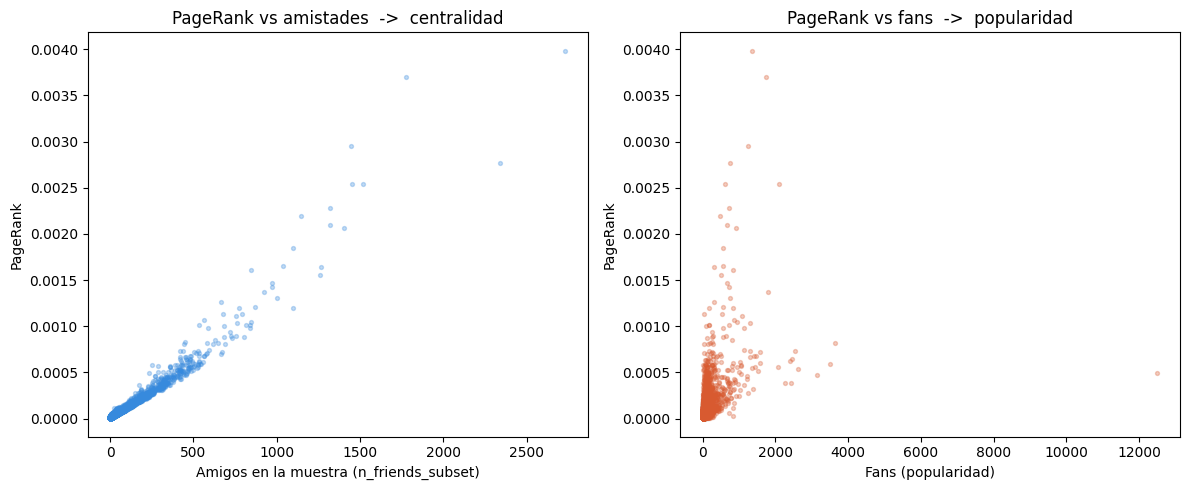

corr PageRank ~ n_friends_subset: 0.977
corr PageRank ~ fans:            0.479
corr PageRank ~ review_count:    0.364


In [0]:
import matplotlib.pyplot as plt
import pandas as pd

# PageRank + atributos para TODOS los usuarios del LCC
prdf = (pd.Series(pr, name='pagerank').rename_axis('user_id').reset_index()
        .merge(clean['users'][['user_id', 'name', 'fans', 'n_friends_subset', 'review_count']],
               on='user_id', how='left'))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(prdf['n_friends_subset'], prdf['pagerank'], s=8, alpha=0.3, color='#378ADD')
axes[0].set_xlabel('Amigos en la muestra (n_friends_subset)'); axes[0].set_ylabel('PageRank')
axes[0].set_title('PageRank vs amistades  ->  centralidad')

axes[1].scatter(prdf['fans'], prdf['pagerank'], s=8, alpha=0.3, color='#D85A30')
axes[1].set_xlabel('Fans (popularidad)'); axes[1].set_ylabel('PageRank')
axes[1].set_title('PageRank vs fans  ->  popularidad')
plt.tight_layout(); plt.show()

print('corr PageRank ~ n_friends_subset:', round(prdf['pagerank'].corr(prdf['n_friends_subset']), 3))
print('corr PageRank ~ fans:           ', round(prdf['pagerank'].corr(prdf['fans']), 3))
print('corr PageRank ~ review_count:   ', round(prdf['pagerank'].corr(prdf['review_count']), 3))

### HITS sobre el grafo bipartito

In [0]:
# load_mod lee los .py directo desde disco (evita el cache de imports del Workspace)
import sys, os, importlib.util

def load_mod(name):
    path = os.path.join(os.getcwd(), name + '.py')
    assert os.path.exists(path), f'No existe {path}: corre primero su celda %%writefile'
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    sys.modules[name] = mod
    spec.loader.exec_module(mod)
    return mod

ranking = load_mod('ranking')

import pandas as pd

u2b, b2u = ranking.build_review_graph(clean['reviews'])
hub, auth, it = ranking.hits(u2b, b2u)
print(f'HITS convergio en {it} iteraciones')
print(f'  {len(u2b):,} hubs (usuarios) | {len(b2u):,} authorities (negocios)\n')

print('TOP 15 AUTHORITIES (negocios mas importantes segun HITS):')
display(ranking.top_authorities(auth, clean['business'], k=15))

print('TOP 15 HUBS (resenadores mas importantes segun HITS):')
display(ranking.top_hubs(hub, clean['users'], k=15))

# authority vs simple popularidad
authdf = (pd.Series(auth, name='authority').rename_axis('business_id').reset_index()
.merge(clean['business'][['business_id', 'review_count']], on='business_id'))
print('corr authority ~ review_count:', round(authdf['authority'].corr(authdf['review_count']), 3))

HITS convergio en 39 iteraciones
  103,449 hubs (usuarios) | 2,943 authorities (negocios)

TOP 15 AUTHORITIES (negocios mas importantes segun HITS):


business_id,authority,name,stars,review_count,categories
8uF-bhJFgT4Tn6DTb27viA,0.991537658669685,District Donuts Sliders Brew,4.5,2062,"Food, Donuts, Burgers, American (Traditional), Coffee & Tea, Restaurants"
j8JOZvfeHEfUWq3gEz6ABQ,0.10594159824000544,Bacchanal Fine Wine & Spirits,4.5,1156,"Jazz & Blues, Bars, Arts & Entertainment, Beer, Wine & Spirits, Wine Bars, Food, Nightlife"
aH3xlewNKQk5K4mEko6qQQ,0.03379252181113539,Midway Pizza,4.0,339,"Restaurants, Pizza"
gLaxSkjWzt25hybkaKwQcA,0.031367286403032,Slim Goodies Diner,3.5,520,"Diners, Cajun/Creole, Breakfast & Brunch, American (Traditional), Restaurants"
5CbJgHWgvjyDRw9Sl4BXhg,0.029342842270386277,Yo Mama's Bar & Grill,4.0,825,"Pubs, Dive Bars, Nightlife, Bars, Restaurants, Burgers"
nTBStZYJfHGdSZJbpaBiPA,0.024822146349433433,The Grill,4.0,933,"American (New), Food, Breakfast & Brunch, American (Traditional), Restaurants, Coffee & Tea, Burgers"
TvbJq1a1Xto5w6t4zMUYHQ,0.018613911954466912,Vessel NOLA,4.0,397,"Desserts, Cocktail Bars, Nightlife, Breakfast & Brunch, Bars, Food, Tapas/Small Plates, American (New), Restaurants"
DnuRO4i1yI5REm5v1pUxWQ,0.01810401417410006,Melba's,3.5,554,"Food, Ice Cream & Frozen Yogurt, Coffee & Tea, Chicken Wings, Sandwiches, Restaurants, Cajun/Creole"
0O3FAdHUwqSwdue0CEW_jw,0.01217623506355201,The Creole Creamery,4.5,165,"Food, Desserts, Ice Cream & Frozen Yogurt"
OxXMZfaRZc7SJnjMBkO1ww,0.011525873611635427,Taceaux Loceaux,4.5,131,"Restaurants, Mexican, Food Trucks, Food, Food Stands, Street Vendors"


TOP 15 HUBS (resenadores mas importantes segun HITS):


user_id,hub,name,review_count,fans,n_friends_subset
Xw7ZjaGfr0WNVt6s_5KZfA,0.029325684768235948,Marielle,2272,379,380
1HM81n6n4iPIFU5d2Lokhw,0.029099670350951276,Shannon,2317,149,161
CfX4sTIFFNaRchNswqhVfg,0.027307622148412265,Christopher,1405,114,184
_kcHxYPXRYjU4hk2xtCO0w,0.0262712069727183,Faith,582,64,102
7lTCFIslGM0MXlMvd2Mu9w,0.025939169385346544,Kimberly,241,33,66
riWDgbauId8TK7YFVgMNJw,0.02580987790773109,Rene,810,86,151
5tXRxr4T24Awl7vjyCvIcQ,0.025658146031691934,Morgan,741,543,1035
iT1AA74QFn_a0Xq9-ggSGA,0.02557520361465489,John L.,2017,237,276
iZpzJ9k4dDgBjuC27MbjvQ,0.025533508948378244,Lindsay,344,27,75
6NagSmaahFhlt3LEpnVXoQ,0.025497746162855838,John,441,9,22


corr authority ~ review_count: 0.426


### Louvain -> comunidades

In [0]:
%%writefile communities.py
"""
communities.py -- Parte II: deteccion de comunidades con Louvain.
Louvain a mano: movimiento local + agregacion por niveles. Sin librerias de grafos.
"""
from collections import defaultdict, Counter
import pandas as pd


def _build_weighted(adjacency):
    return {i: (dict(nbrs) if isinstance(nbrs, dict) else {j: 1.0 for j in nbrs})
            for i, nbrs in adjacency.items()}


def induced_subgraph(adj, nodes):
    s = set(nodes)
    return {u: {v for v in adj[u] if v in s} for u in nodes}


def _one_level(adj_w, m, resolution):
    nodes = list(adj_w)
    com = {i: i for i in nodes}
    k = {i: sum(adj_w[i].values()) for i in nodes}
    tot = dict(k)
    improved, any_imp = True, False
    while improved:
        improved = False
        for i in nodes:
            ci, ki = com[i], k[i]
            neigh = defaultdict(float)
            for j, w in adj_w[i].items():
                if j != i:
                    neigh[com[j]] += w
            tot[ci] -= ki
            best_c = ci
            best_gain = neigh.get(ci, 0.0) - resolution * tot[ci] * ki / (2 * m)
            for c, kin in neigh.items():
                gain = kin - resolution * tot[c] * ki / (2 * m)
                if gain > best_gain:
                    best_c, best_gain = c, gain
            tot[best_c] += ki
            com[i] = best_c
            if best_c != ci:
                improved = any_imp = True
    return com, any_imp


def louvain(adjacency, resolution=1.0, max_levels=50):
    adj_w = _build_weighted(adjacency)
    m = sum(sum(d.values()) for d in adj_w.values()) / 2.0
    if m == 0:
        return {i: 0 for i in adj_w}
    partition = {i: i for i in adj_w}
    cur = adj_w
    for _ in range(max_levels):
        com, improved = _one_level(cur, m, resolution)
        relab = {c: idx for idx, c in enumerate(sorted(set(com.values()), key=str))}
        com = {n: relab[c] for n, c in com.items()}
        partition = {orig: com[sup] for orig, sup in partition.items()}
        if not improved:
            break
        new = defaultdict(lambda: defaultdict(float))
        for i in cur:
            ci = com[i]
            for j, w in cur[i].items():
                new[ci][com[j]] += w
        cur = {c: dict(d) for c, d in new.items()}
    order = [c for c, _ in Counter(partition.values()).most_common()]
    remap = {c: idx for idx, c in enumerate(order)}
    return {n: remap[c] for n, c in partition.items()}


def modularity(adjacency, partition):
    adj_w = _build_weighted(adjacency)
    m = sum(sum(d.values()) for d in adj_w.values()) / 2.0
    if m == 0:
        return 0.0
    inc, tot = defaultdict(float), defaultdict(float)
    for i in adj_w:
        ci = partition[i]
        tot[ci] += sum(adj_w[i].values())
        for j, w in adj_w[i].items():
            if partition[j] == ci:
                inc[ci] += w
    return sum(inc[c] / (2 * m) - (tot[c] / (2 * m)) ** 2 for c in tot)


def community_summary(adj, partition, pr=None, users=None, top_k=5, n_key=5):
    members = defaultdict(list)
    for n, c in partition.items():
        members[c].append(n)
    name_map = dict(zip(users['user_id'], users['name'])) if users is not None else {}
    rows = []
    for c, ms_list in sorted(members.items(), key=lambda kv: -len(kv[1]))[:top_k]:
        ms = set(ms_list)
        n = len(ms)
        ein = sum(1 for u in ms for v in adj[u] if v in ms) // 2
        eout = sum(1 for u in ms for v in adj[u] if v not in ms)
        density = 2 * ein / (n * (n - 1)) if n > 1 else 0
        if pr:
            key = sorted(ms, key=lambda x: pr.get(x, 0), reverse=True)[:n_key]
        else:
            key = sorted(ms, key=lambda x: len(adj[x]), reverse=True)[:n_key]
        rows.append({'comunidad': c, 'tamano': n, 'aristas_int': ein,
                     'densidad_int': round(density, 4), 'aristas_ext': eout,
                     'miembros_clave': [name_map.get(u, u) for u in key]})
    return pd.DataFrame(rows)

Writing communities.py


In [0]:
# load_mod lee los .py directo desde disco (evita el cache de imports del Workspace)
import sys, os, importlib.util

def load_mod(name):
    path = os.path.join(os.getcwd(), name + '.py')
    assert os.path.exists(path), f'No existe {path}: corre primero su celda %%writefile'
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    sys.modules[name] = mod
    spec.loader.exec_module(mod)
    return mod

communities = load_mod('communities')

lcc_adj = communities.induced_subgraph(G['friend_adj'], G['lcc'])
partition = communities.louvain(lcc_adj)
q = communities.modularity(lcc_adj, partition)
print(f'Louvain: {len(set(partition.values())):,} comunidades | modularidad Q = {q:.4f}')

summary = communities.community_summary(lcc_adj, partition, pr=pr, users=clean['users'], top_k=5)
summary

Louvain: 140 comunidades | modularidad Q = 0.6556


,comunidad,tamano,aristas_int,densidad_int,aristas_ext,miembros_clave
0,0,8891,54831,0.0014,17030,"[Michelle, Steven, Morris, Alisha, Karen]"
1,1,5989,45022,0.0025,41197,"[Abby, Phil, Randy, Christine, Katie]"
2,2,5913,41385,0.0024,16117,"[Kaitlyn, Christina, Brett, Ginger, Brian]"
3,3,3429,20717,0.0035,4943,"[Niki, Brittany, Chad, Jon, Richard]"
4,4,3411,18448,0.0032,7040,"[Aaron, Aimee, Christy, Max, Virginia]"


### Dibujando el grafo

In [0]:
%%writefile graphviz.py
import math
import random
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


def sample_subgraph(adj, partition, n_comms=6, per_comm=50, seed=0):
    rng = random.Random(seed)
    members = defaultdict(list)
    for n, c in partition.items():
        members[c].append(n)
    top = sorted(members, key=lambda c: -len(members[c]))[:n_comms]
    sampled, node_comm = set(), {}
    for c in top:
        ms = members[c]
        pick = ms if len(ms) <= per_comm else rng.sample(ms, per_comm)
        for u in pick:
            sampled.add(u)
            node_comm[u] = c
    sub = {u: [v for v in adj[u] if v in sampled] for u in sampled}
    return sub, node_comm


def spring_layout(sub, iterations=100, seed=0):
    rng = random.Random(seed)
    nodes = list(sub)
    n = len(nodes)
    if n == 0:
        return {}
    pos = {u: [rng.uniform(0, 1), rng.uniform(0, 1)] for u in nodes}
    edges = set()
    for u in sub:
        for v in sub[u]:
            edges.add((u, v) if str(u) < str(v) else (v, u))
    k = math.sqrt(1.0 / n)
    t = 0.1
    dt = t / (iterations + 1)
    for _ in range(iterations):
        disp = {u: [0.0, 0.0] for u in nodes}
        for i in range(n):
            ui = nodes[i]; xi, yi = pos[ui]
            for j in range(i + 1, n):
                uj = nodes[j]
                dx = xi - pos[uj][0]; dy = yi - pos[uj][1]
                d = math.hypot(dx, dy) or 1e-6
                rep = k * k / d
                ux, uy = dx / d * rep, dy / d * rep
                disp[ui][0] += ux; disp[ui][1] += uy
                disp[uj][0] -= ux; disp[uj][1] -= uy
        for u, v in edges:
            dx = pos[u][0] - pos[v][0]; dy = pos[u][1] - pos[v][1]
            d = math.hypot(dx, dy) or 1e-6
            att = d * d / k
            ax_, ay_ = dx / d * att, dy / d * att
            disp[u][0] -= ax_; disp[u][1] -= ay_
            disp[v][0] += ax_; disp[v][1] += ay_
        for u in nodes:
            dx, dy = disp[u]
            d = math.hypot(dx, dy) or 1e-6
            lim = min(d, t)
            pos[u][0] += dx / d * lim
            pos[u][1] += dy / d * lim
        t -= dt
    return {u: tuple(p) for u, p in pos.items()}


def plot_communities(sub, node_comm, pos, pr=None, title=None):
    fig, ax = plt.subplots(figsize=(9, 9))
    for u in sub:
        for v in sub[u]:
            if str(u) < str(v):
                ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
                        color='#cccccc', lw=0.3, alpha=0.5, zorder=1)
    comms = sorted(set(node_comm.values()))
    cmap = plt.cm.tab10
    color = {c: cmap(i % 10) for i, c in enumerate(comms)}
    nodes = list(sub)
    if pr:
        mx = max((pr.get(u, 0) for u in nodes), default=0) or 1.0
        sizes = [15 + 220 * (pr.get(u, 0) / mx) for u in nodes]
    else:
        sizes = [25] * len(nodes)
    ax.scatter([pos[u][0] for u in nodes], [pos[u][1] for u in nodes],
               c=[color[node_comm[u]] for u in nodes], s=sizes,
               edgecolors='white', linewidths=0.3, zorder=2)
    handles = [mpatches.Patch(color=color[c], label=f'Comunidad {c}') for c in comms]
    ax.legend(handles=handles, loc='upper right', fontsize=8, framealpha=0.9)
    ax.set_title(title or 'Comunidades de amistad (muestra del LCC)')
    ax.axis('off')
    plt.tight_layout(); plt.show()

Writing graphviz.py


Muestra: 300 nodos de las 6 comunidades mas grandes


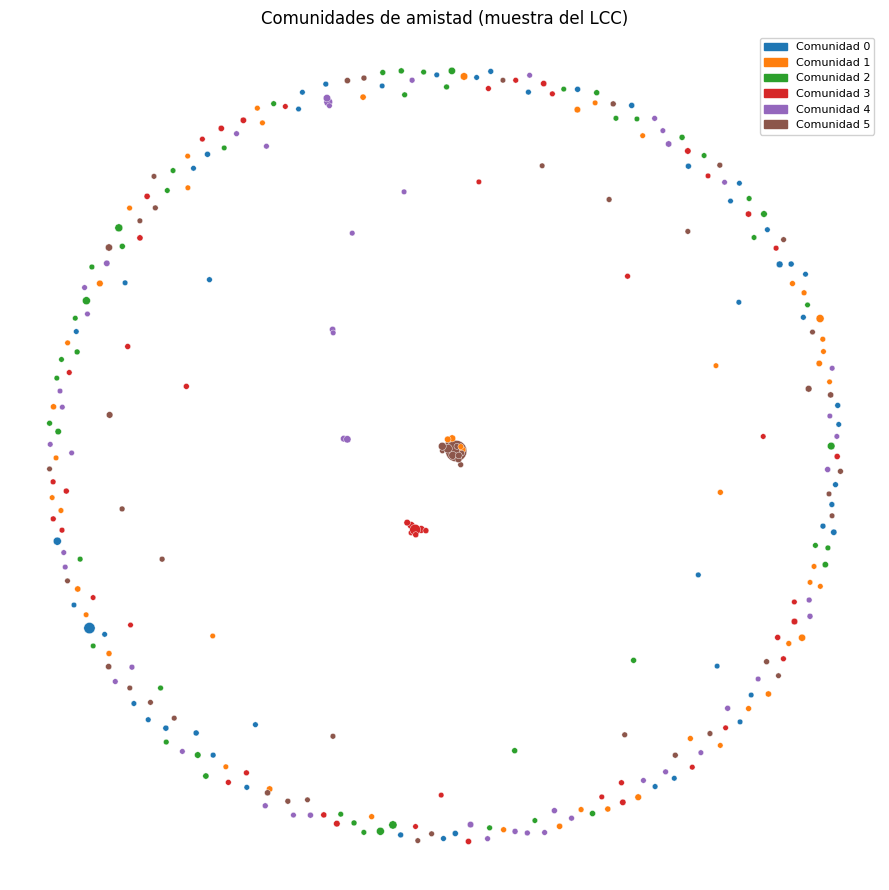

In [0]:
# load_mod lee los .py directo desde disco (evita el cache de imports del Workspace)
import sys, os, importlib.util

def load_mod(name):
    path = os.path.join(os.getcwd(), name + '.py')
    assert os.path.exists(path), f'No existe {path}: corre primero su celda %%writefile'
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    sys.modules[name] = mod
    spec.loader.exec_module(mod)
    return mod

graphviz = load_mod('graphviz')

sub, node_comm = graphviz.sample_subgraph(lcc_adj, partition, n_comms=6, per_comm=50)
print(f'Muestra: {len(sub):,} nodos de las 6 comunidades mas grandes')

pos = graphviz.spring_layout(sub, iterations=120)
graphviz.plot_communities(sub, node_comm, pos, pr=pr,
title='Comunidades de amistad (muestra del LCC)')

Las comunidades grandes son enormes (de 2,110 a 9,167 nodos las top-8) pero internamente dispersas (densidad interna entre 0.0013 y 0.0053).

Cuando muestreo 50 nodos al azar de una comunidad de miles, la probabilidad de que dos de ellos estén conectados directamente es bajísima: quedan apenas un puñado de aristas por comunidad. O sea, la mayoría de los 300 nodos muestreados quedan aislados (sin aristas entre sí). Y en un layout force-directed, los nodos sin aristas solo sienten repulsión, así que se van todos al borde formando ese anillo. Los pocos cumulitos del centro son los que sí quedaron conectados.

### Version mejorada

In [0]:
%%writefile graphviz.py
import math
import random
from collections import defaultdict, deque
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


def sample_subgraph(adj, partition, pr=None, n_comms=6, per_comm=50, seed=0):
    members = defaultdict(list)
    for n, c in partition.items():
        members[c].append(n)
    top = sorted(members, key=lambda c: -len(members[c]))[:n_comms]
    sampled, node_comm = set(), {}
    for c in top:
        ms = set(members[c])
        if pr:
            seed_node = max(ms, key=lambda x: pr.get(x, 0))
        else:
            seed_node = max(ms, key=lambda x: sum(1 for v in adj[x] if v in ms))
        seen, dq, order = {seed_node}, deque([seed_node]), []
        while dq and len(order) < per_comm:
            u = dq.popleft()
            order.append(u)
            for v in adj[u]:
                if v in ms and v not in seen:
                    seen.add(v)
                    dq.append(v)
        for u in order:
            sampled.add(u)
            node_comm[u] = c
    sub = {u: [v for v in adj[u] if v in sampled] for u in sampled}
    return sub, node_comm


def spring_layout(sub, iterations=100, seed=0):
    rng = random.Random(seed)
    nodes = list(sub)
    n = len(nodes)
    if n == 0:
        return {}
    pos = {u: [rng.uniform(0, 1), rng.uniform(0, 1)] for u in nodes}
    edges = set()
    for u in sub:
        for v in sub[u]:
            edges.add((u, v) if str(u) < str(v) else (v, u))
    k = math.sqrt(1.0 / n)
    t = 0.1
    dt = t / (iterations + 1)
    for _ in range(iterations):
        disp = {u: [0.0, 0.0] for u in nodes}
        for i in range(n):
            ui = nodes[i]; xi, yi = pos[ui]
            for j in range(i + 1, n):
                uj = nodes[j]
                dx = xi - pos[uj][0]; dy = yi - pos[uj][1]
                d = math.hypot(dx, dy) or 1e-6
                rep = k * k / d
                ux, uy = dx / d * rep, dy / d * rep
                disp[ui][0] += ux; disp[ui][1] += uy
                disp[uj][0] -= ux; disp[uj][1] -= uy
        for u, v in edges:
            dx = pos[u][0] - pos[v][0]; dy = pos[u][1] - pos[v][1]
            d = math.hypot(dx, dy) or 1e-6
            att = d * d / k
            ax_, ay_ = dx / d * att, dy / d * att
            disp[u][0] -= ax_; disp[u][1] -= ay_
            disp[v][0] += ax_; disp[v][1] += ay_
        for u in nodes:
            dx, dy = disp[u]
            d = math.hypot(dx, dy) or 1e-6
            lim = min(d, t)
            pos[u][0] += dx / d * lim
            pos[u][1] += dy / d * lim
        t -= dt
    return {u: tuple(p) for u, p in pos.items()}


def plot_communities(sub, node_comm, pos, pr=None, title=None):
    fig, ax = plt.subplots(figsize=(9, 9))
    for u in sub:
        for v in sub[u]:
            if str(u) < str(v):
                ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
                        color='#cccccc', lw=0.3, alpha=0.5, zorder=1)
    comms = sorted(set(node_comm.values()))
    cmap = plt.cm.tab10
    color = {c: cmap(i % 10) for i, c in enumerate(comms)}
    nodes = list(sub)
    if pr:
        mx = max((pr.get(u, 0) for u in nodes), default=0) or 1.0
        sizes = [15 + 220 * (pr.get(u, 0) / mx) for u in nodes]
    else:
        sizes = [25] * len(nodes)
    ax.scatter([pos[u][0] for u in nodes], [pos[u][1] for u in nodes],
               c=[color[node_comm[u]] for u in nodes], s=sizes,
               edgecolors='white', linewidths=0.3, zorder=2)
    handles = [mpatches.Patch(color=color[c], label=f'Comunidad {c}') for c in comms]
    ax.legend(handles=handles, loc='upper right', fontsize=8, framealpha=0.9)
    ax.set_title(title or 'Comunidades de amistad (muestra del LCC)')
    ax.axis('off')
    plt.tight_layout(); plt.show()

Overwriting graphviz.py


Muestra: 300 nodos | aristas: 672


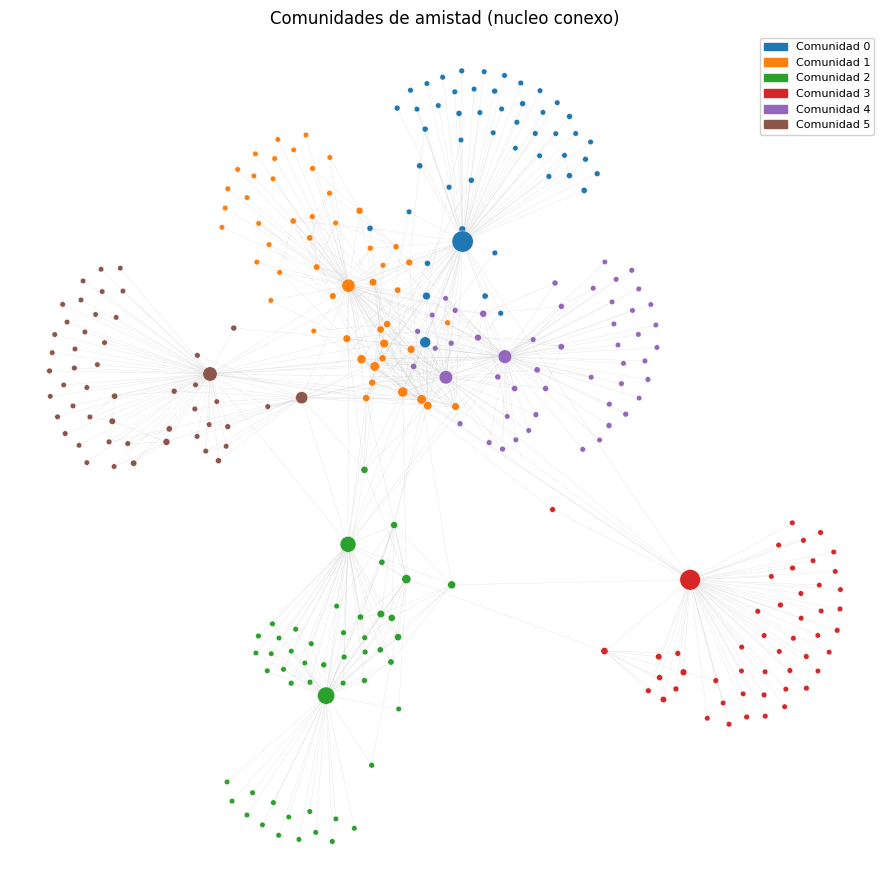

In [0]:
# load_mod lee los .py directo desde disco (evita el cache de imports del Workspace)
import sys, os, importlib.util

def load_mod(name):
    path = os.path.join(os.getcwd(), name + '.py')
    assert os.path.exists(path), f'No existe {path}: corre primero su celda %%writefile'
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    sys.modules[name] = mod
    spec.loader.exec_module(mod)
    return mod

graphviz = load_mod('graphviz')

sub, node_comm = graphviz.sample_subgraph(lcc_adj, partition, pr=pr, n_comms=6, per_comm=50)
print(f'Muestra: {len(sub):,} nodos | aristas: {sum(len(v) for v in sub.values())//2:,}')

pos = graphviz.spring_layout(sub, iterations=120)
graphviz.plot_communities(sub, node_comm, pos, pr=pr,
title='Comunidades de amistad (nucleo conexo)')

## Comparador Lentes de influencia

In [0]:
import pandas as pd

infl = (pd.concat([pd.Series(pr, name='pagerank'),
                   pd.Series(hub, name='hub')], axis=1, join='inner')
        .rename_axis('user_id').reset_index()
        .merge(clean['users'][['user_id', 'name', 'review_count', 'fans', 'n_friends_subset']],
               on='user_id', how='left'))
infl['pr_rank']  = infl['pagerank'].rank(ascending=False, method='min').astype(int)
infl['hub_rank'] = infl['hub'].rank(ascending=False, method='min').astype(int)

print('corr  PageRank ~ hub:', round(infl['pagerank'].corr(infl['hub']), 3))
top_pr  = set(infl.nsmallest(15, 'pr_rank')['user_id'])
top_hub = set(infl.nsmallest(15, 'hub_rank')['user_id'])
overlap = top_pr & top_hub
print(f'Solapamiento top-15 (influencia social vs reseñador): {len(overlap)}/15')

pilares = (infl[infl.user_id.isin(overlap)].sort_values('pagerank', ascending=False)
           [['name', 'pr_rank', 'hub_rank', 'review_count', 'fans', 'n_friends_subset']])
print('\nPilares de la red (top en AMBOS lentes):')
display(pilares)

corr  PageRank ~ hub: 0.023
Solapamiento top-15 (influencia social vs reseñador): 1/15

Pilares de la red (top en AMBOS lentes):


name,pr_rank,hub_rank,review_count,fans,n_friends_subset
Morgan,12,7,741,543,1035


### Lectura de resultados de la Parte II

**PageRank mide capital social, no actividad.** Sobre el LCC de 41,832 usuarios convergio en 40 iteraciones y correlaciona casi perfecto con las amistades dentro de la muestra (corr = 0.98) pero mucho menos con fans (0.48) y con review_count (0.36): se puede ser muy influyente en la red social escribiendo relativamente poco.

**HITS mide otra cosa.** Los top authorities son negocios gastronomicos con cientos o miles de resenas (District Donuts Sliders Brew y Bacchanal Fine Wine & Spirits a la cabeza), pero la correlacion authority ~ review_count es solo 0.43: HITS pondera *quien* te resena, no cuantos. Los top hubs son usuarios prolificos (Marielle con 2,272 resenas, Shannon con 2,317) que no necesariamente tienen muchos amigos.

**Los dos lentes casi no se solapan.** corr PageRank ~ hub = 0.023 y el top-15 de ambos rankings comparte **una sola persona (Morgan**, #12 social y #7 resenadora): ser influyente en la red de amistades y ser un resenador de referencia son roles distintos en Yelp. Morgan es el raro "pilar" que cumple ambos.

**Louvain** encontro 191 comunidades con modularidad Q = 0.654 (estructura comunitaria fuerte). Las 8 mayores concentran ~39k de los ~42k nodos del LCC (de 2,110 a 9,167 miembros) con densidades internas de 0.0013-0.0053: comunidades enormes y dispersas, tipico de redes sociales grandes, lo que explica el aspecto del grafo muestreado de arriba.